# Strava Cycling Analysis
**Dec 2024 – May 2026** · Virtual Rides & Outdoor Rides

Sections:
1. Data loading & cleaning
2. Activity overview
3. Distance & volume trends
4. Speed analysis
5. Heart rate zones
6. Power (watts) analysis
7. Cadence analysis
8. Elevation & effort
9. Virtual vs outdoor comparison
10. Personal records

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
ORANGE = '#FC4C02'  # Strava orange
BLUE   = '#2563EB'
GREEN  = '#16A34A'

## 1. Data loading & cleaning

In [ ]:
df_raw = pd.read_csv('activities.csv')

# Keep cycling only
df = df_raw[df_raw['Activity Type'].isin(['Virtual Ride', 'Ride'])].copy()

# Parse date
df['date'] = pd.to_datetime(df['Activity Date'], format='%b %d, %Y, %I:%M:%S %p', errors='coerce')
df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

# Distance is already in km; speed in m/s, time in seconds
df['distance_km']   = df['Distance']
df['moving_time_h'] = df['Moving Time'] / 3600
df['speed_kmh']     = df['Average Speed'] * 3.6
df['max_speed_kmh'] = df['Max Speed'] * 3.6
df['elev_gain_m']   = df['Elevation Gain']

# Derived columns
df['month']       = df['date'].dt.to_period('M')
df['week']        = df['date'].dt.to_period('W')
df['day_of_week'] = df['date'].dt.day_name()
df['is_virtual']  = df['Activity Type'] == 'Virtual Ride'

print(f"Rides loaded: {len(df)}")
print(f"Date range:   {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Virtual rides: {df['is_virtual'].sum()} | Outdoor rides: {(~df['is_virtual']).sum()}")
df[['date','Activity Name','Activity Type','distance_km','moving_time_h','speed_kmh','elev_gain_m',
    'Average Heart Rate','Average Watts','Average Cadence','Calories']].head()

## 2. Activity overview

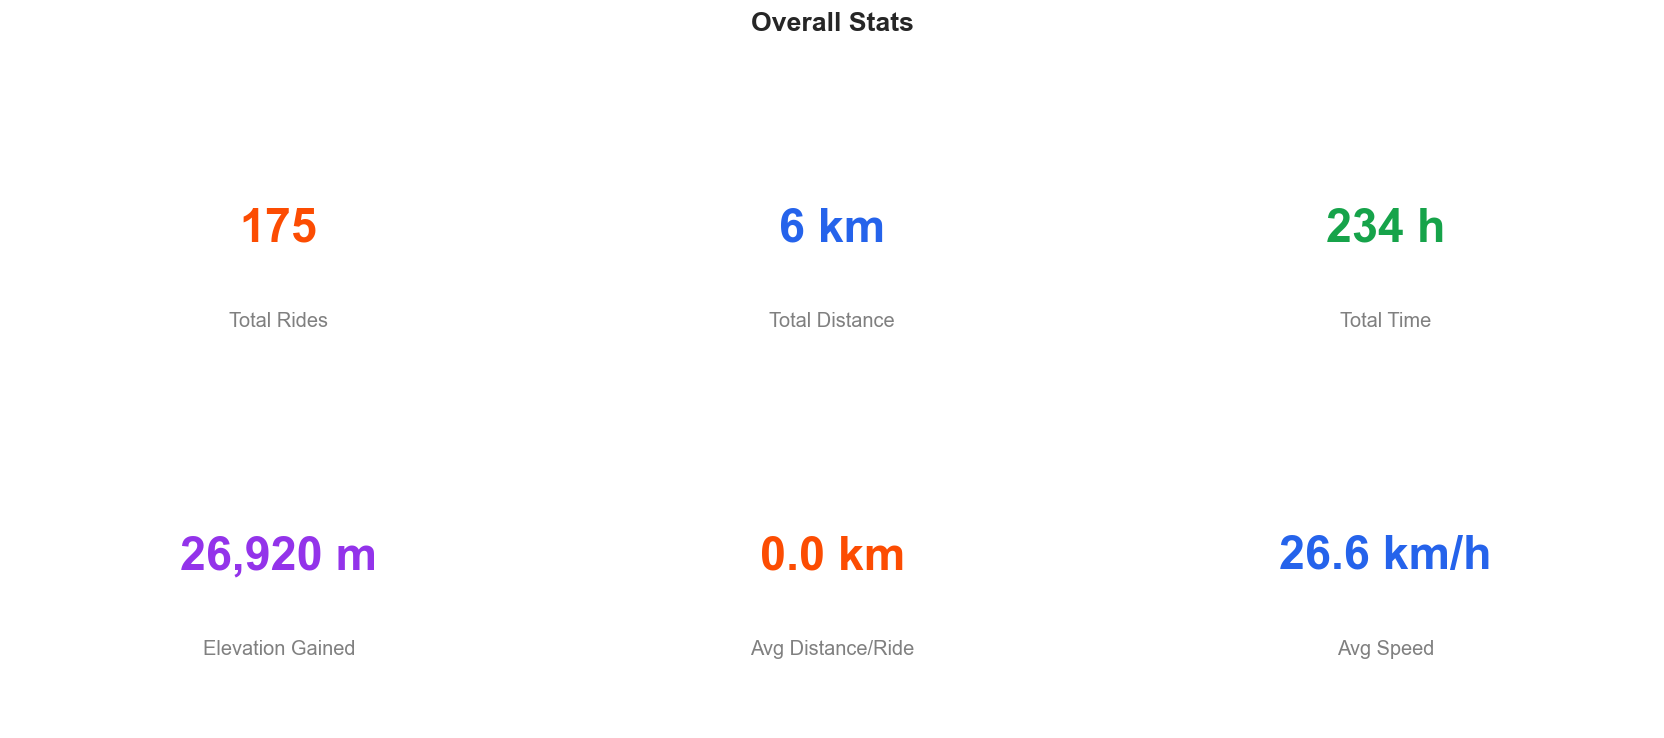

In [7]:
total_dist  = df['distance_km'].sum()
total_time  = df['moving_time_h'].sum()
total_elev  = df['elev_gain_m'].sum()
total_cal   = df['Calories'].sum()
avg_dist    = df['distance_km'].mean()
avg_speed   = df['speed_kmh'].mean()

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
stats = [
    ('Total Rides',       f"{len(df)}",             ORANGE),
    ('Total Distance',    f"{total_dist:,.0f} km",  BLUE),
    ('Total Time',        f"{total_time:,.0f} h",   GREEN),
    ('Elevation Gained',  f"{total_elev:,.0f} m",   '#9333EA'),
    ('Avg Distance/Ride', f"{avg_dist:.1f} km",     ORANGE),
    ('Avg Speed',         f"{avg_speed:.1f} km/h",  BLUE),
]
for ax, (label, value, color) in zip(axes.flat, stats):
    ax.text(0.5, 0.55, value, ha='center', va='center', fontsize=28,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=12,
            color='gray', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Overall Stats', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Rides per day-of-week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(day_counts.index, day_counts.values, color=ORANGE, alpha=0.85, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Rides by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of rides')
ax.set_ylim(0, day_counts.max() * 1.2)
plt.tight_layout()
plt.show()

## 3. Distance & volume trends

In [ ]:
monthly = df.groupby('month').agg(
    rides=('distance_km', 'count'),
    total_km=('distance_km', 'sum'),
    total_h=('moving_time_h', 'sum'),
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Distance bars
ax1.bar(monthly['month_dt'], monthly['total_km'], width=20, color=ORANGE, alpha=0.85, label='Total km')
ax1.set_ylabel('Distance (km)', color=ORANGE)
ax1.tick_params(axis='y', labelcolor=ORANGE)
ax1_twin = ax1.twinx()
ax1_twin.plot(monthly['month_dt'], monthly['rides'], 'o-', color=BLUE, lw=2, label='# rides')
ax1_twin.set_ylabel('# Rides', color=BLUE)
ax1_twin.tick_params(axis='y', labelcolor=BLUE)
ax1.set_title('Monthly Distance & Ride Count', fontsize=13, fontweight='bold')

# Hours bars
ax2.bar(monthly['month_dt'], monthly['total_h'], width=20, color=GREEN, alpha=0.85)
ax2.set_ylabel('Hours on bike')
ax2.set_title('Monthly Hours on Bike', fontsize=13, fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Cumulative distance over time
df_sorted = df.sort_values('date')
df_sorted['cumulative_km'] = df_sorted['distance_km'].cumsum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(df_sorted['date'], df_sorted['cumulative_km'], alpha=0.25, color=ORANGE)
ax.plot(df_sorted['date'], df_sorted['cumulative_km'], color=ORANGE, lw=2)
ax.set_title('Cumulative Distance Over Time', fontsize=14, fontweight='bold')
ax.set_ylabel('km')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Speed analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['speed_kmh'].dropna(), bins=25, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['speed_kmh'].mean(), color=ORANGE, lw=2, linestyle='--',
                label=f"Mean: {df['speed_kmh'].mean():.1f} km/h")
axes[0].set_title('Average Speed Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Speed (km/h)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Speed over time (rolling 10-ride mean)
df_sorted = df.sort_values('date').copy()
df_sorted['speed_roll10'] = df_sorted['speed_kmh'].rolling(10, min_periods=1).mean()
axes[1].scatter(df_sorted['date'], df_sorted['speed_kmh'], alpha=0.3, color=BLUE, s=20)
axes[1].plot(df_sorted['date'], df_sorted['speed_roll10'], color=ORANGE, lw=2,
             label='10-ride rolling mean')
axes[1].set_title('Speed Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('km/h')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Speed by ride type
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='speed_kmh', by='Activity Type', ax=ax,
           boxprops=dict(color=BLUE), medianprops=dict(color=ORANGE, lw=2),
           whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
ax.set_title('Speed by Ride Type', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('km/h')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Heart rate zones

In [ ]:
# Adjust max HR if you know your actual value
MAX_HR = df['Max Heart Rate'].max()
print(f"Max HR seen in data: {MAX_HR:.0f} bpm")

def hr_zone(hr, max_hr=MAX_HR):
    pct = hr / max_hr * 100
    if pct < 60:  return 'Z1 Recovery'
    elif pct < 70: return 'Z2 Endurance'
    elif pct < 80: return 'Z3 Tempo'
    elif pct < 90: return 'Z4 Threshold'
    else:          return 'Z5 VO2max'

df['hr_zone'] = df['Average Heart Rate'].apply(lambda x: hr_zone(x) if pd.notna(x) else None)
zone_order = ['Z1 Recovery','Z2 Endurance','Z3 Tempo','Z4 Threshold','Z5 VO2max']
zone_colors = ['#60A5FA','#34D399','#FBBF24','#F97316','#EF4444']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Zone distribution pie
zone_counts = df['hr_zone'].value_counts().reindex(zone_order, fill_value=0)
wedges, texts, autotexts = axes[0].pie(
    zone_counts, labels=zone_counts.index,
    autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
    colors=zone_colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Rides by HR Zone', fontsize=13, fontweight='bold')

# Avg HR over time
df_sorted = df.sort_values('date').copy()
df_sorted['hr_roll10'] = df_sorted['Average Heart Rate'].rolling(10, min_periods=1).mean()
sc = axes[1].scatter(df_sorted['date'], df_sorted['Average Heart Rate'],
                     c=[zone_colors[zone_order.index(z)] if z in zone_order else 'gray'
                        for z in df_sorted['hr_zone'].fillna('Z1 Recovery')],
                     alpha=0.6, s=25)
axes[1].plot(df_sorted['date'], df_sorted['hr_roll10'], color='black', lw=1.5,
             label='10-ride mean')
axes[1].set_title('Average HR Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('bpm')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# HR vs speed scatter
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df['speed_kmh'], df['Average Heart Rate'],
                c=df['is_virtual'].map({True: ORANGE, False: BLUE}),
                alpha=0.6, s=40)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=ORANGE, label='Virtual Ride', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=BLUE, label='Outdoor Ride', markersize=8),
]
ax.legend(handles=legend_elements)
ax.set_xlabel('Average Speed (km/h)')
ax.set_ylabel('Average Heart Rate (bpm)')
ax.set_title('Heart Rate vs Speed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Power (watts) analysis

In [ ]:
df_power = df.dropna(subset=['Average Watts']).copy()
print(f"Rides with power data: {len(df_power)} / {len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Power histogram
axes[0].hist(df_power['Average Watts'], bins=25, color=GREEN, edgecolor='white', alpha=0.85)
axes[0].axvline(df_power['Average Watts'].mean(), color=ORANGE, lw=2, linestyle='--',
                label=f"Mean: {df_power['Average Watts'].mean():.0f} W")
axes[0].set_title('Average Power Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Watts')
axes[0].set_ylabel('Count')
axes[0].legend()

# Power over time
df_power_sorted = df_power.sort_values('date')
df_power_sorted['watts_roll10'] = df_power_sorted['Average Watts'].rolling(10, min_periods=1).mean()
axes[1].scatter(df_power_sorted['date'], df_power_sorted['Average Watts'],
                alpha=0.35, color=GREEN, s=25)
axes[1].plot(df_power_sorted['date'], df_power_sorted['watts_roll10'],
             color=ORANGE, lw=2, label='10-ride rolling mean')
axes[1].set_title('Average Power Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Watts')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Power vs HR — aerobic efficiency proxy
fig, ax = plt.subplots(figsize=(8, 5))
df_both = df.dropna(subset=['Average Watts','Average Heart Rate']).copy()

# Use days since first ride as color value — avoids int64/epoch issues
df_both['days'] = (df_both['date'] - df_both['date'].min()).dt.days

sc = ax.scatter(df_both['Average Heart Rate'], df_both['Average Watts'],
                c=df_both['days'], cmap='RdYlGn', alpha=0.7, s=40)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Date (green = recent)')

# Label colorbar ticks with readable dates
tick_days = np.linspace(0, df_both['days'].max(), 5)
cbar.set_ticks(tick_days)
cbar.set_ticklabels([
    (df_both['date'].min() + pd.Timedelta(days=int(d))).strftime('%b %Y')
    for d in tick_days
])

ax.set_xlabel('Average Heart Rate (bpm)')
ax.set_ylabel('Average Watts')
ax.set_title('Power vs HR (color = time — green is more recent)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Cadence analysis

In [ ]:
df_cad = df.dropna(subset=['Average Cadence']).copy()
print(f"Rides with cadence data: {len(df_cad)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_cad['Average Cadence'], bins=20, color='#9333EA', edgecolor='white', alpha=0.85)
axes[0].axvline(df_cad['Average Cadence'].mean(), color=ORANGE, lw=2, linestyle='--',
                label=f"Mean: {df_cad['Average Cadence'].mean():.0f} rpm")
axes[0].axvline(90, color='gray', lw=1.5, linestyle=':', label='90 rpm target')
axes[0].set_title('Cadence Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('rpm')
axes[0].legend()

# Cadence over time
df_cad_sorted = df_cad.sort_values('date')
df_cad_sorted['cad_roll10'] = df_cad_sorted['Average Cadence'].rolling(10, min_periods=1).mean()
axes[1].scatter(df_cad_sorted['date'], df_cad_sorted['Average Cadence'],
                alpha=0.35, color='#9333EA', s=25)
axes[1].plot(df_cad_sorted['date'], df_cad_sorted['cad_roll10'],
             color=ORANGE, lw=2, label='10-ride mean')
axes[1].axhline(90, color='gray', lw=1.5, linestyle=':', label='90 rpm')
axes[1].set_title('Cadence Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('rpm')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Elevation & effort

In [ ]:
# Elevation gain per ride over time
df_outdoor = df[~df['is_virtual']].sort_values('date')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elevation per km (climbing rate)
df_outdoor['elev_per_km'] = df_outdoor['elev_gain_m'] / df_outdoor['distance_km']
axes[0].scatter(df_outdoor['date'], df_outdoor['elev_per_km'], color=GREEN, alpha=0.7, s=40)
axes[0].set_title('Elevation Gain per km (Outdoor Rides)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('m/km')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=30)

# Relative effort distribution
df_re = df.dropna(subset=['Relative Effort'])
axes[1].hist(df_re['Relative Effort'], bins=25, color=ORANGE, edgecolor='white', alpha=0.85)
axes[1].axvline(df_re['Relative Effort'].mean(), color=BLUE, lw=2, linestyle='--',
                label=f"Mean: {df_re['Relative Effort'].mean():.0f}")
axes[1].set_title('Relative Effort Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Relative Effort')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap of key metrics
cols_corr = ['distance_km','moving_time_h','speed_kmh','elev_gain_m',
             'Average Heart Rate','Average Watts','Average Cadence',
             'Relative Effort','Calories']
corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Metric Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Virtual vs outdoor comparison

In [ ]:
compare_cols = ['distance_km','moving_time_h','speed_kmh','Average Heart Rate',
                'Average Watts','Average Cadence','Relative Effort','Calories']
compare_labels = ['Distance (km)','Time (h)','Speed (km/h)','Avg HR (bpm)',
                  'Avg Power (W)','Cadence (rpm)','Relative Effort','Calories']

virtual  = df[df['is_virtual']]
outdoor  = df[~df['is_virtual']]

v_means = [virtual[c].mean() for c in compare_cols]
o_means = [outdoor[c].mean() for c in compare_cols]

x = np.arange(len(compare_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, v_means, width, label='Virtual Ride', color=ORANGE, alpha=0.85)
bars2 = ax.bar(x + width/2, o_means, width, label='Outdoor Ride', color=BLUE, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_labels, rotation=25, ha='right')
ax.set_title('Average Metrics: Virtual vs Outdoor Rides', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylabel('Mean value')
plt.tight_layout()
plt.show()

# Print table
comp_df = pd.DataFrame({'Metric': compare_labels,
                        'Virtual Ride': [f"{v:.1f}" for v in v_means],
                        'Outdoor Ride': [f"{o:.1f}" for o in o_means]})
comp_df.style.set_caption('Virtual vs Outdoor — mean values')

## 10. Personal records

In [ ]:
records = {
    'Longest ride (km)':       df.loc[df['distance_km'].idxmax()],
    'Fastest avg speed':       df.loc[df['speed_kmh'].idxmax()],
    'Highest HR ride':         df.loc[df['Average Heart Rate'].dropna().idxmax()],
    'Most elevation (outdoor)': df_outdoor.loc[df_outdoor['elev_gain_m'].idxmax()] if len(df_outdoor) else None,
    'Highest avg power':       df.loc[df['Average Watts'].dropna().idxmax()],
    'Highest relative effort': df.loc[df['Relative Effort'].dropna().idxmax()],
}

rows = []
for title, row in records.items():
    if row is None: continue
    rows.append({
        'Record': title,
        'Date': row['date'].date(),
        'Activity': row['Activity Name'][:50],
        'Value': (
            f"{row['distance_km']:.1f} km"       if 'Longest' in title else
            f"{row['speed_kmh']:.1f} km/h"       if 'speed' in title else
            f"{row['Average Heart Rate']:.0f} bpm" if 'HR' in title else
            f"{row['elev_gain_m']:.0f} m"         if 'elevation' in title else
            f"{row['Average Watts']:.0f} W"       if 'power' in title else
            f"{row['Relative Effort']:.0f}"
        )
    })

pd.DataFrame(rows).style.set_caption('Personal Records').hide(axis='index')

In [ ]:
# Top 10 longest rides
top10 = df.nlargest(10, 'distance_km')[['date','Activity Name','Activity Type',
                                         'distance_km','moving_time_h','speed_kmh',
                                         'elev_gain_m','Average Heart Rate']]
top10.columns = ['Date','Name','Type','Distance (km)','Time (h)','Speed (km/h)',
                 'Elevation (m)','Avg HR']
top10['Date'] = top10['Date'].dt.date
top10['Distance (km)'] = top10['Distance (km)'].round(1)
top10['Time (h)'] = top10['Time (h)'].round(2)
top10['Speed (km/h)'] = top10['Speed (km/h)'].round(1)
top10.style.set_caption('Top 10 Longest Rides').hide(axis='index')

## 11. Comeback story — overview

In [ ]:
monthly = df.groupby(df['date'].dt.to_period('M')).agg(
    rides=('distance_km', 'count'),
    total_km=('distance_km', 'sum'),
    avg_speed=('speed_kmh', 'mean'),
    avg_watts=('Average Watts', 'mean'),
    avg_hr=('Average Heart Rate', 'mean'),
).reset_index()
monthly['month_dt'] = monthly['date'].dt.to_timestamp()

# Define periods
INJURY_START = pd.Timestamp('2025-10-01')
COMEBACK_START = pd.Timestamp('2025-12-01')

def bar_color(dt):
    if dt < INJURY_START:        return ORANGE
    elif dt < COMEBACK_START:    return '#D1D5DB'   # gray = injury gap
    else:                        return BLUE

colors = [bar_color(d) for d in monthly['month_dt']]

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# --- Volume ---
bars = axes[0].bar(monthly['month_dt'], monthly['total_km'], width=22,
                   color=colors, edgecolor='white')
axes[0].axvline(INJURY_START,   color='red',  lw=1.5, linestyle='--', alpha=0.6)
axes[0].axvline(COMEBACK_START, color=GREEN,  lw=1.5, linestyle='--', alpha=0.6)
axes[0].set_ylabel('km / month')
axes[0].set_title('Monthly Distance', fontweight='bold')
for bar, val in zip(bars, monthly['total_km']):
    if val > 50:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# --- Speed ---
axes[1].plot(monthly['month_dt'], monthly['avg_speed'], 'o-', color=ORANGE, lw=2)
axes[1].axvline(INJURY_START,   color='red',  lw=1.5, linestyle='--', alpha=0.6)
axes[1].axvline(COMEBACK_START, color=GREEN,  lw=1.5, linestyle='--', alpha=0.6)
axes[1].fill_between(monthly['month_dt'], monthly['avg_speed'], alpha=0.12, color=ORANGE)
axes[1].set_ylabel('km/h')
axes[1].set_title('Average Speed', fontweight='bold')

# --- Power ---
axes[2].plot(monthly['month_dt'], monthly['avg_watts'], 'o-', color=GREEN, lw=2)
axes[2].axvline(INJURY_START,   color='red',  lw=1.5, linestyle='--', alpha=0.6, label='Injury (Oct)')
axes[2].axvline(COMEBACK_START, color=GREEN,  lw=1.5, linestyle='--', alpha=0.6, label='Comeback (Dec)')
axes[2].fill_between(monthly['month_dt'], monthly['avg_watts'].fillna(method='ffill'),
                     alpha=0.12, color=GREEN)
axes[2].set_ylabel('Watts')
axes[2].set_title('Average Power', fontweight='bold')
axes[2].legend()

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

fig.suptitle('Training Timeline: Before → Injury → Comeback', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Key numbers summary ---
pre   = monthly[monthly['month_dt'] < INJURY_START]
post  = monthly[monthly['month_dt'] >= COMEBACK_START]
best_post = post.iloc[-2] if len(post) >= 2 else post.iloc[-1]  # last full month

print("=" * 52)
print(f"  Pre-injury peak (Aug 2025)")
print(f"    Distance:  {monthly.loc[monthly['total_km'].idxmax(), 'total_km']:.0f} km/month")
print(f"    Speed:     {pre['avg_speed'].max():.1f} km/h")
print(f"    Power:     {pre['avg_watts'].max():.0f} W")
print()
print(f"  Best comeback month ({best_post['date']})")
print(f"    Distance:  {best_post['total_km']:.0f} km/month")
print(f"    Speed:     {best_post['avg_speed']:.1f} km/h  (+{best_post['avg_speed'] - pre['avg_speed'].max():.1f} vs pre-injury peak)")
print(f"    Power:     {best_post['avg_watts']:.0f} W  (+{best_post['avg_watts'] - pre['avg_watts'].max():.0f} vs pre-injury peak)")
print("=" * 52)

## 12. Season forecast (Jun – Sep 2026)

In [ ]:
# Use post-comeback months (Dec 2025 – Apr 2026) as the trend basis.
# Speed & power use log fit (diminishing returns as fitness plateaus).
# Volume uses linear fit capped at a realistic ceiling.

post_full = monthly[(monthly['month_dt'] >= COMEBACK_START) &
                    (monthly['month_dt'] < '2026-05-01')].copy().reset_index(drop=True)
post_full['x'] = np.arange(len(post_full))   # 0=Dec, 1=Jan, 2=Feb, 3=Mar, 4=Apr

forecast_months = pd.date_range('2026-06-01', periods=4, freq='MS')  # Jun–Sep
forecast_x      = np.arange(len(post_full), len(post_full) + 4)      # 5,6,7,8

# ── Speed: log fit (gains slow down) ────────────────────────────────────
spd_valid = post_full.dropna(subset=['avg_speed'])
log_x     = np.log1p(spd_valid['x'])
spd_coeffs = np.polyfit(log_x, spd_valid['avg_speed'], 1)
spd_hist_fit  = spd_coeffs[0] * np.log1p(post_full['x']) + spd_coeffs[1]
spd_forecast  = spd_coeffs[0] * np.log1p(forecast_x)     + spd_coeffs[1]

# ── Power: log fit ───────────────────────────────────────────────────────
pwr_valid  = post_full.dropna(subset=['avg_watts'])
log_xp     = np.log1p(pwr_valid['x'])
pwr_coeffs = np.polyfit(log_xp, pwr_valid['avg_watts'], 1)
pwr_hist_fit  = pwr_coeffs[0] * np.log1p(post_full['x']) + pwr_coeffs[1]
pwr_forecast  = pwr_coeffs[0] * np.log1p(forecast_x)     + pwr_coeffs[1]

# ── Volume: linear fit, capped at 1.3× pre-injury peak ──────────────────
VOLUME_CAP    = monthly[monthly['month_dt'] < INJURY_START]['total_km'].max() * 1.3
km_coeffs     = np.polyfit(post_full['x'], post_full['total_km'], 1)
km_hist_fit   = np.polyfit(post_full['x'], post_full['total_km'], 1)
km_forecast   = np.clip(km_coeffs[0] * forecast_x + km_coeffs[1], 0, VOLUME_CAP)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

all_months = list(post_full['month_dt']) + list(forecast_months)
hist_x     = post_full['month_dt']

def add_forecast_band(ax, forecast_months, values, color):
    lo = values * 0.93
    hi = values * 1.07
    ax.fill_between(forecast_months, lo, hi, alpha=0.18, color=color)

# Speed
axes[0].plot(hist_x, post_full['avg_speed'], 'o-', color=ORANGE, lw=2, label='Actual')
axes[0].plot(hist_x, spd_hist_fit, '--', color=ORANGE, lw=1, alpha=0.5)
axes[0].plot(forecast_months, spd_forecast, 's--', color=ORANGE, lw=2,
             markersize=8, label='Forecast')
add_forecast_band(axes[0], forecast_months, spd_forecast, ORANGE)
for dt, val in zip(forecast_months, spd_forecast):
    axes[0].annotate(f'{val:.1f}', (dt, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, color=ORANGE, fontweight='bold')
axes[0].set_ylabel('km/h')
axes[0].set_title('Average Speed Forecast', fontweight='bold')
axes[0].legend()
axes[0].axvspan(forecast_months[0], forecast_months[-1] + pd.Timedelta(days=30),
                alpha=0.05, color=ORANGE)

# Power
axes[1].plot(hist_x, post_full['avg_watts'], 'o-', color=GREEN, lw=2, label='Actual')
axes[1].plot(hist_x, pwr_hist_fit, '--', color=GREEN, lw=1, alpha=0.5)
axes[1].plot(forecast_months, pwr_forecast, 's--', color=GREEN, lw=2,
             markersize=8, label='Forecast')
add_forecast_band(axes[1], forecast_months, pwr_forecast, GREEN)
for dt, val in zip(forecast_months, pwr_forecast):
    axes[1].annotate(f'{val:.0f}W', (dt, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, color=GREEN, fontweight='bold')
axes[1].set_ylabel('Watts')
axes[1].set_title('Average Power Forecast', fontweight='bold')
axes[1].legend()
axes[1].axvspan(forecast_months[0], forecast_months[-1] + pd.Timedelta(days=30),
                alpha=0.05, color=GREEN)

# Volume
axes[2].bar(hist_x, post_full['total_km'], width=22, color=BLUE, alpha=0.7, label='Actual')
axes[2].bar(forecast_months, km_forecast, width=22, color=BLUE, alpha=0.35,
            label='Forecast', edgecolor=BLUE, linewidth=1.5)
for dt, val in zip(forecast_months, km_forecast):
    axes[2].text(dt, val + 15, f'{val:.0f}', ha='center', fontsize=9,
                 color=BLUE, fontweight='bold')
axes[2].axhline(VOLUME_CAP, color='gray', lw=1.2, linestyle=':', label=f'Cap ({VOLUME_CAP:.0f} km)')
axes[2].set_ylabel('km / month')
axes[2].set_title('Monthly Volume Forecast', fontweight='bold')
axes[2].legend()
axes[2].axvspan(forecast_months[0], forecast_months[-1] + pd.Timedelta(days=30),
                alpha=0.05, color=BLUE)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

fig.suptitle('Season Forecast — Jun to Sep 2026\n(shaded band = ±7% range)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────
print(f"\n{'Month':<12} {'Speed (km/h)':>14} {'Power (W)':>10} {'Volume (km)':>12}")
print("-" * 50)
for dt, spd, pwr, km in zip(forecast_months, spd_forecast, pwr_forecast, km_forecast):
    print(f"{dt.strftime('%b %Y'):<12} {spd:>14.1f} {pwr:>10.0f} {km:>12.0f}")
print("-" * 50)
print(f"\nNote: forecast assumes consistent training at current trajectory.")
print(f"Speed & power use a log curve (gains slow as fitness plateaus).")
print(f"Volume capped at {VOLUME_CAP:.0f} km/month (130% of your pre-injury peak).")